![Architecture of LeNet-5](figures/LeNet-5_Figure.png "LeNet-5")

### Environment Setup

In [130]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import random
import time
import numpy as np
from torch import nn

### Data Loading & Normalization

In [2]:
def load_dataset(root='../cnn_scratch_nieNazwa/data', transform=transforms.ToTensor()):
    train_set = torchvision.datasets.CIFAR10(root=root, train=True, transform=transform, download=True)
    val_set = torchvision.datasets.CIFAR10(root=root, train=False, transform=transform, download=True)
    return train_set, val_set

In [3]:
train_data, val_data = load_dataset()

100.0%


In [6]:
len(train_data), len(train_data[0]), train_data[0][0].shape

(50000, 2, torch.Size([3, 32, 32]))

In [7]:
len(val_data), len(val_data[0]), val_data[0][0].shape

(10000, 2, torch.Size([3, 32, 32]))

In [8]:
def Stats_PerChannel(data, get=False):
    imgs = torch.stack([img for img, _ in data])
    
    min_vals = imgs.amin(dim=(0, 2, 3))
    max_vals = imgs.amax(dim=(0, 2, 3))
    print(f"Min vals: {min_vals}\tMax vals: {max_vals}\n")
    
    means = torch.mean(imgs, dim=(0, 2, 3))
    stds = torch.std(imgs, dim=(0, 2, 3))
    print(f"Mean: {means}\tStd: {stds}")

    if get:
        m = tuple(round(x, 5) for x in means.tolist())
        s = tuple(round(x, 5) for x in stds.tolist())
        return m, s

In [9]:
norm_mean, norm_std = Stats_PerChannel(train_data, get=True)

Min vals: tensor([0., 0., 0.])	Max vals: tensor([1., 1., 1.])

Mean: tensor([0.4914, 0.4822, 0.4465])	Std: tensor([0.2470, 0.2435, 0.2616])


In [10]:
norm_mean, norm_std

((0.4914, 0.48216, 0.44653), (0.24703, 0.24349, 0.26159))

In [11]:
train_data, val_data = load_dataset(transform=transforms.Compose([transforms.ToTensor(),
     transforms.Normalize(norm_mean, norm_std)]))

In [12]:
Stats_PerChannel(train_data)

Min vals: tensor([-1.9892, -1.9802, -1.7070])	Max vals: tensor([2.0589, 2.1267, 2.1158])

Mean: tensor([-1.2720e-06, -6.4988e-06,  3.4809e-06])	Std: tensor([1.0000, 1.0000, 1.0000])


In [13]:
torch.tensor(norm_mean)

tensor([0.4914, 0.4822, 0.4465])

### Visualizing the dataset

In [14]:
classes = {0: 'plane', 1: 'car', 2: 'bird', 3: 'cat', 4: 'deer', 
           5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

In [15]:
def imshow(img, lbl, m, s):
    mean, std = torch.tensor(m), torch.tensor(s)
    
    img = img * std[:, None, None] + mean[:, None, None]   
    img.clamp_(0, 1)
    
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(lbl)

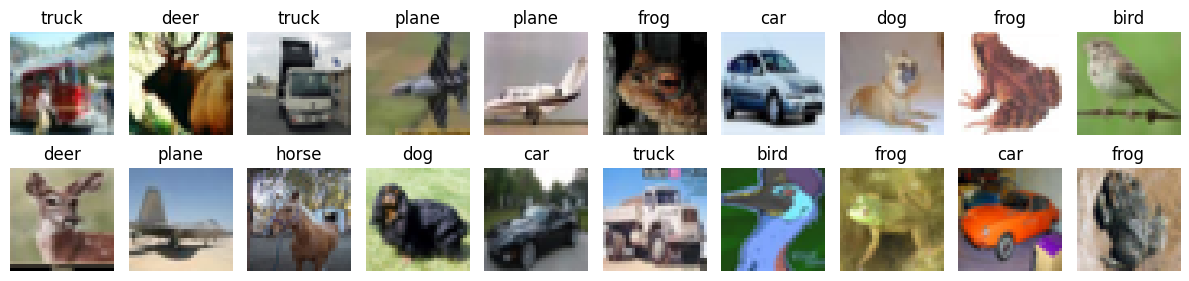

In [17]:
rand_idx = random.sample(range(0, len(train_data)), 20)

figure = plt.figure(figsize=(12, 3), tight_layout=True)

for i, idx  in enumerate(rand_idx):
    img, label = train_data[idx]
    figure.add_subplot(2, 10, i+1)
    imshow(img, classes[label], norm_mean, norm_std)
plt.show()

## Architecture

<center>
  <img src="figures/LeNet-5_Figure.png" width="750">
</center>

### Cross-Coorelation

#### Since LeNet does not implement padding and stride above 1 in any convolutional layer we may calculate output shape by simple formula:
- #### Number of Filters, (Input_height - Kernel_height + 1), (Input_width - Kernel_width + 1) - do poprawy

## Pack That shit in The class !!!!!

### I didn't want to just call nn.Conv2d() and treat it like a black box. This is my "from-scratch" implementation of the LeNet-5 architecture, focusing on the actual tensor logic behind convolutional layers.
#### This is my understanding and method

In [4]:
"""Conv Layer Class"""

'Conv Layer Class'

In [111]:
class PoolLayer():
    def __init__(self, k_size, stride, p_type='avg'):
        self.K_h, self.K_w = k_size
        self.stride = stride
        
        """ Setting Pooling function """
        if p_type == 'avg':
            self.func = torch.mean
        else:
            self.func = torch.amax

    def calc_pool(self, X):
        X_c, X_h, X_w = X.shape[0], X.shape[1], X.shape[2]
        Y = torch.zeros(X_c, (X_h - self.K_h)//self.stride + 1,
                        (X_w - self.K_w)//self.stride + 1)

        for i, i_x in enumerate(range(0, X_h - self.K_h + 1, self.stride)):
            for j, j_x in enumerate(range(0, X_w - self.K_w + 1, self.stride)):
                x_slice = X[:, i_x: i_x + self.K_h, j_x: j_x + self.K_w]
                Y[:, i, j] = self.func(x_slice, dim=(1, 2))
        return Y

    def forward(self, X):
        return torch.stack([self.calc_pool(x) for x in X])

In [116]:
class LinearLayer(nn.Module):
    def __init__(self, num_in, num_out):
        super().__init__()

        """ He Kaiming Initialization """
        std = np.sqrt(2.0 / num_in)

        """ Defining Parameters """
        self.W = torch.nn.Parameter(torch.randn(num_in, num_out) * std)
        self.b = torch.nn.Parameter(torch.zeros(num_out))

    def forward(X):
        return torch.matmul(X, self.W) + self.b

In [115]:
class ConvLayer(nn.Module):
    def __init__(self, k_size, num_in, num_out):
        super().__init__()
        self.K_h, self.K_w = k_size
        self.K_c = num_out
        
        """ He Kaiming Initialization """
        fan_in = num_in * self.K_h * self.K_w
        std = np.sqrt(2.0 / fan_in)

        """ Defining Parameters """
        self.K = torch.nn.Parameter(
            torch.randn(self.K_c, num_in, self.K_h, self.K_w) * std)
        
        self.b = torch.nn.Parameter(torch.zeros(num_out, 1, 1))

    def cross_coor(self, X):
        X_h, X_w = X.shape[1], X.shape[2]
        Y = torch.zeros(self.K_c, X_h - self.K_h + 1, X_w - self.K_w + 1)
        
        for i in range(Y.shape[1]):
            for j in range(Y.shape[2]):
                x_slice = X[:, i: i+self.K_h, j: j+self.K_w]         
                Y[:, i, j] = (x_slice.unsqueeze(dim=0) * self.K).sum(dim=(1, 2, 3))       
        return Y + self.b 

    
    def forward(self, X):
        return torch.stack([self.cross_coor(x) for x in X])

In [ ]:
class LeNet_5(nn.Module):
    def __init__(self, lr):
        super().__init__()
        self.lr = lr

        self.Conv_1 = ConvLayer(k_size=(5, 5), num_in=3, num_out=6)
        self.Pool_1 = PoolLayer(k_size=(2, 2), stride=2, p_type='avg')
        self.Conv_2 = ConvLayer(k_size=(5, 5), num_in=6, num_out=16)
        self.Pool_2 = PoolLayer(k_size=(2, 2), stride=2, p_type='avg')
        
        self.Linear_1 = LinearLayer(num_in=400, num_out=120)
        self.Linear_2 = LinearLayer(num_in=120, num_out=84)
        self.Linear_3 = LinearLayer(num_in=84, num_out=10)

    def forward(self, X):
        X = F.relu(self.Conv_1.forward(X))
        

        

In [108]:
test = PoolLayer((2, 2), 2, 'avg')

In [132]:
test.calc_pool(torch.randn(3, 28, 28)).shape

torch.Size([3, 14, 14])

In [137]:
test2 = PoolLayer((2, 2), 2, 'avg')
F.relu(test2.calc_pool(torch.randn(3, 28, 28)))

tensor([[[0.3333, 0.0000, 0.0000, 0.0000, 0.1343, 1.3191, 0.1977, 0.0000,
          0.0000, 0.1836, 0.0000, 0.6450, 0.1316, 0.0000],
         [0.5920, 0.6415, 0.0000, 0.0000, 0.0000, 0.0000, 0.0824, 0.0000,
          0.0000, 0.0000, 0.1516, 0.0000, 0.4688, 0.0000],
         [0.0000, 0.1304, 0.2128, 0.8430, 0.0000, 0.5586, 0.0000, 0.0000,
          0.0000, 0.6449, 0.0000, 0.7146, 0.0040, 0.9267],
         [0.0000, 0.0128, 0.0000, 0.5885, 0.0000, 0.0000, 0.0000, 0.8931,
          0.0000, 0.6226, 0.0813, 0.0000, 1.2062, 0.3086],
         [0.0000, 0.4799, 0.5686, 0.0000, 0.0000, 1.3348, 0.0908, 0.0000,
          0.0000, 0.4927, 0.0000, 0.3797, 0.5901, 0.0000],
         [0.1666, 0.2696, 0.5837, 0.6200, 0.0000, 0.0000, 0.6495, 0.6196,
          0.0000, 0.4054, 0.3014, 0.3627, 0.3171, 0.2561],
         [0.3926, 0.0000, 0.1138, 0.0062, 0.0000, 0.5563, 0.1522, 0.0000,
          0.0094, 0.0000, 0.2145, 0.0000, 0.0000, 0.4521],
         [0.0000, 0.7917, 0.3271, 0.0000, 0.3390, 0.0000, 0.2631, 0.0

In [22]:
X_test = train_data[0][0]
X_test.shape

torch.Size([3, 32, 32])

In [23]:
b_test = torch.ones(6, 1, 1)
b_test

tensor([[[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]]])

In [81]:
test_flat = torch.ones(5, 4, 3, 3)
test_flat.reshape(test_flat.shape[0], -1).shape

torch.Size([5, 36])

In [85]:
K_test = torch.randn(6, 3, 5, 5)
K_test

tensor([[[[ 1.5504, -2.0225, -0.6721,  1.2130, -2.2791],
          [-0.2175, -0.8179, -0.9191,  0.9328, -0.7798],
          [-0.3588,  0.1466, -0.2303,  0.2343,  0.7532],
          [-0.7762, -1.0667, -0.1344,  0.6126,  0.5239],
          [ 0.1582, -0.4939,  0.3053,  1.5371, -0.9628]],

         [[ 2.2987, -0.1376,  0.4754, -0.9878, -0.9637],
          [ 0.6155, -1.3377, -0.2419,  1.3629,  2.2515],
          [ 0.8166, -0.3723,  0.9888, -0.2623, -0.9976],
          [-0.4093,  1.0587,  0.4902, -0.9832, -0.5469],
          [-0.6435, -1.5605, -0.6943, -0.8696, -0.5680]],

         [[ 0.4759,  1.0523,  0.5749, -1.2280,  0.9138],
          [-0.6459, -0.3353, -1.1786,  0.0996, -0.7671],
          [ 0.5059,  0.6792, -0.6924,  1.4922, -0.2430],
          [-0.9681,  1.6358,  0.7285,  1.3547,  1.7260],
          [ 0.2275, -1.1201, -0.1960, -1.6029, -0.8477]]],


        [[[-1.7485, -0.3337,  0.2358, -0.6138,  0.1882],
          [ 0.0648, -0.0061, -1.0550,  0.5164, -1.1055],
          [ 0.0048,  0.

In [65]:
def data_loader(data, is_train, batch_size):
    return torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=is_train, num_workers=1)

In [69]:
tic = time.time()
for X, y in data_loader(train_data, True, 256):
    continue
f'{time.time() - tic:.2f} sec'

'13.75 sec'

In [84]:
X, y = next(iter(data_loader(train_data, True, 256)))
X.shape, y.shape

(torch.Size([256, 3, 32, 32]), torch.Size([256]))

In [91]:
K_test.shape

torch.Size([6, 3, 5, 5])